# CSCI218 Group Assignment: Income predicition with Machine Learning
---
Group: FT7

Group Members:
- Yuxiang Chen
- Marcela Fioneta
- Haoran Gao
- Zhihui Liu
- Yijia Wang
- Lorenzo Sayo Yanga

Code authored by Lorenzo Sayo Yanga

Reviewer:
- Marcela Fioneta
- Haoran Gao
- Zhihui Liu
- Yijia Wang
- Yuxiang Chen

# **Installing and importing**
importing all the libraries needed for building the machine learning


In [ ]:
# Installing the ucimlrepo package
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

**Import Adult Dataset from UC Irvine Machine Learning Repository**

Adult dataset source: https://archive.ics.uci.edu/ml/datasets/Adult

In [ ]:
# Manual file reading, because UCI repo didn't update their SSL cert on 22/2
def load_adult_dataset_manual():
  df_rawdata = pd.read_csv("/content/adult.data", header=None, skipinitialspace=True)
  df_rawtest = pd.read_csv("/content/adult.test", header=None, skipinitialspace=True, skiprows=1)
  df = pd.concat([df_rawdata, df_rawtest])
  # Manually define column names
  df.columns = [
      "age", "workclass", "fnlwgt", "education", "education-num",
      "marital-status", "occupation", "relationship", "race", "sex",
      "capital-gain", "capital-loss", "hours-per-week", "native-country",
      "income"
  ]
  return df

def load_adult_dataset():
  # fetch dataset from UCI repository

  adult = fetch_ucirepo(name="Adult")

  X = adult.data.features
  y = adult.data.targets

  # return a dataframe: combined features with the target
  df = pd.concat([X,y], axis = 1)
  return df

# display the dataset to help us understand which needed for data cleaning
# and preprocessing
def data_inspection(df):
  print("Dataset Shape:", df.shape)
  print("\nFirst 5 Rows:")
  print(df.head())
  print("\nMissing Values:")
  print(df.isnull().sum())
  print("\nData Types:")
  print(df.dtypes)

if __name__ == "__main__":
  # load the dataset
  df = load_adult_dataset()
  # df = load_adult_dataset_manual()

  # do data inspection
  data_inspection(df)

Dataset Shape: (48842, 15)

First 5 Rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  


Do some rechecking for each column as null values like "?" is not automatically identified as missing.


In [ ]:
for col in df.columns:
    print(col, df[col].unique())

age [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]
workclass ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' nan]
fnlwgt [ 77516  83311 215646 ... 173449  89686 350977]
education ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
education-num [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital-status ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Prot

Analysing how education-num and education columns are related

In [ ]:
# see row with each value in education-num corresponds to education's value
for i in sorted(df['education-num'].unique()):
    print(f"education-num ({i}): {df[df['education-num'] == i]['education'].unique()}")

education-num (1): ['Preschool']
education-num (2): ['1st-4th']
education-num (3): ['5th-6th']
education-num (4): ['7th-8th']
education-num (5): ['9th']
education-num (6): ['10th']
education-num (7): ['11th']
education-num (8): ['12th']
education-num (9): ['HS-grad']
education-num (10): ['Some-college']
education-num (11): ['Assoc-voc']
education-num (12): ['Assoc-acdm']
education-num (13): ['Bachelors']
education-num (14): ['Masters']
education-num (15): ['Prof-school']
education-num (16): ['Doctorate']


# Analysis of dataset:

**Outliers present:**
- capital-gain (99999) and hours-per-week (99)
  - These values may have initially represented extreme values (>99999, >99) which could have skewed the distribution of the dataset and negatively affected model performance.
  - Since they have been already been constrained like this, we can leave these values as-is.

**fnlwgt column**
  - Could be some kind of population weighting
    - Intended for data analysis, does not add any characteristic to the row itself and should be removed.

**education, education-num**
  - education: Can be relevant to determine the salary, but represented in categorical value.
  - education-num: encoded version of education, is in logical order (education qualification).
    - education column can be dropped.

**Missing values**
- There is an existance of missing values (NaN).
  - There is null values that are represented as "?" strings.
  - Rows with either case will be removed from the dataset.

**Income**
- Because we used fetch_ucirepo to import the dataset, the training and test data is combined.
  - However test data has '.' on values at the end of income (e.g. "<=50K.", "<=50K")
  - It will need to be fixed during preprocessing.

**native-country**
- There are ~40 countries, but United-States makes up 90% of the data. This means there is an imbalance in class.
  - More than half the countries have less than 100 people in them
  - One-hot encoding can result in dataset being too sparse (curse of dimensionality)

In [ ]:
# Get numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("--- Distributions for Numerical Columns ")
for col in numerical_cols:
    print(f"\nColumn: {col}")
    print(df[col].describe())
    print("\nSkewness:", df[col].skew())

print("\n--- Distributions for Categorical Columns ---")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)

--- Distributions for Numerical Columns 

Column: age
count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

Skewness: 0.5575803166133182

Column: fnlwgt
count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

Skewness: 1.4388918785218416

Column: education-num
count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

Skewness: -0.3165248566607419

Column: capital-gain
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000

# Cleaning dataset
When cleaning the dataset, the following is done:
- Rows
  - Rows with NaN values or "?" values (interpreted as null) will be removed.
    - 7.41% of the dataset is removed, bias can potentially be introduced through this.
- Columns
  - 'fnlwgt' is dropped; column is irrelevant to row data
  - 'eduation' is dropped; education-num exists and is already better suited for the ML.



In [ ]:
# Check for any missing data in df
# replace "?" values to NA, for better analysis
df = df.replace('?', np.nan)

print("--- Before Cleaning ---")
print("No. of rows:", len(df))
print("\nRows with missing values")
print(df.isna().sum())

--- Before Cleaning ---
No. of rows: 48842

Rows with missing values
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [ ]:
#do cleaning
df_cleaned = (df.drop(columns=["fnlwgt", "education"]).dropna())
# unify income labels
df_cleaned['income'] = df_cleaned['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

#mapped the income into 2 classes: 0 and 1 for classification
df_cleaned['income'] = df_cleaned['income'].map({'<=50K': 0, '>50K': 1})

# check after cleaning
print("--- After Cleaning ---")
print("No. of rows:", len(df_cleaned))
print(f"% of database lost after cleaning: \
{(len(df) - len(df_cleaned)) / len(df) * 100:.2f} %")
print("\nRows with missing values")
print(df_cleaned.isna().sum())

--- After Cleaning ---
No. of rows: 45222
% of database lost after cleaning: 7.41 %

Rows with missing values
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


Checking the distribution of the cleaned dataset, and if there is an imbalance in the dataset

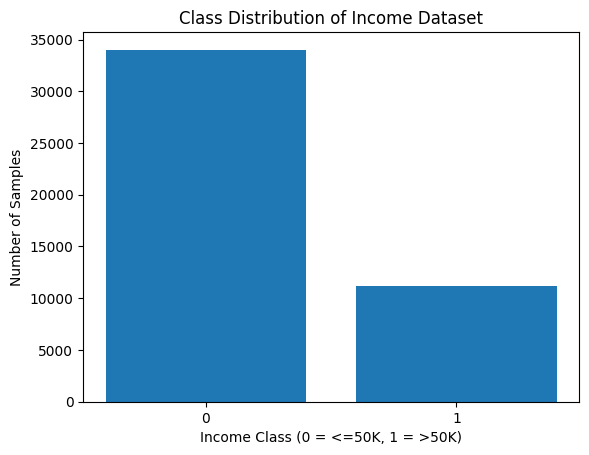

Class Counts:
income
0    34014
1    11208
Name: count, dtype: int64

Class Percentage:
income
0    75.215603
1    24.784397
Name: count, dtype: float64


In [ ]:
# count classes
class_counts = df_cleaned["income"].value_counts().sort_index()

# plot
plt.figure()
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Income Class (0 = <=50K, 1 = >50K)")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Income Dataset")

plt.show()

# print numbers
print("Class Counts:")
print(class_counts)

print("\nClass Percentage:")
print((class_counts / class_counts.sum()) * 100)

### Split the dataset (80/20)

Initially a 60/20/20 split was done (training, validation, test).

Upon implementing GridSearchCV, the validation set was no longer needed as its own set and is hence merged into the training set.

Stratification is done to ensure each set has the same distribution of classes.

`random_state` was set so that results were reproducible.

In [ ]:
X = df_cleaned.drop("income", axis=1)
y = df_cleaned["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

We do preprocessing only after splitting to minimise data leakage.

To ensure optimal performance for all models, processing is done differently for Logistic Regression and Decision Tree/Random Forest:
- Logistic Regression
  - Scaling done to numerical features
  - One-hot encoding done to all categorical features.
- Decision Tree/Random Forest
  - No scaling needed; it does not affect either model's performance
  - Categorical features encoded with OrdinalEncoder, default behaviour encodes in alphanumeric order.

In [ ]:
# define numeric & categorical columns
num_cols = ['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'education-num']
cat_cols = [col for col in X.columns if col not in num_cols]

# ColumnTransformer for logistic regression (scaling, use OneHotEncoder)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# ColumnTransformer for tree models (no scaling, use OrdinalEncoder)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
            ), cat_cols)
    ]
)

**Set** every of the three model to do preprocessing and hyperparameter.

**Before imbalance handling** (From raw data)

In [ ]:
# logistic regression
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000
    ))
])
# decision tree
dt_model = Pipeline(steps=[
      ("preprocessor", preprocessor_tree),
      ("classifier", DecisionTreeClassifier(
          random_state=RANDOM_STATE
      ))
  ])
# random forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE
    ))
])

#train all model
logistic_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'education-num']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

Evaluation on each model


===== Logistic Regression (Baseline) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      6803
        >50K       0.73      0.59      0.65      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.84      0.84      9045


AUC Score: 0.9012961367335055


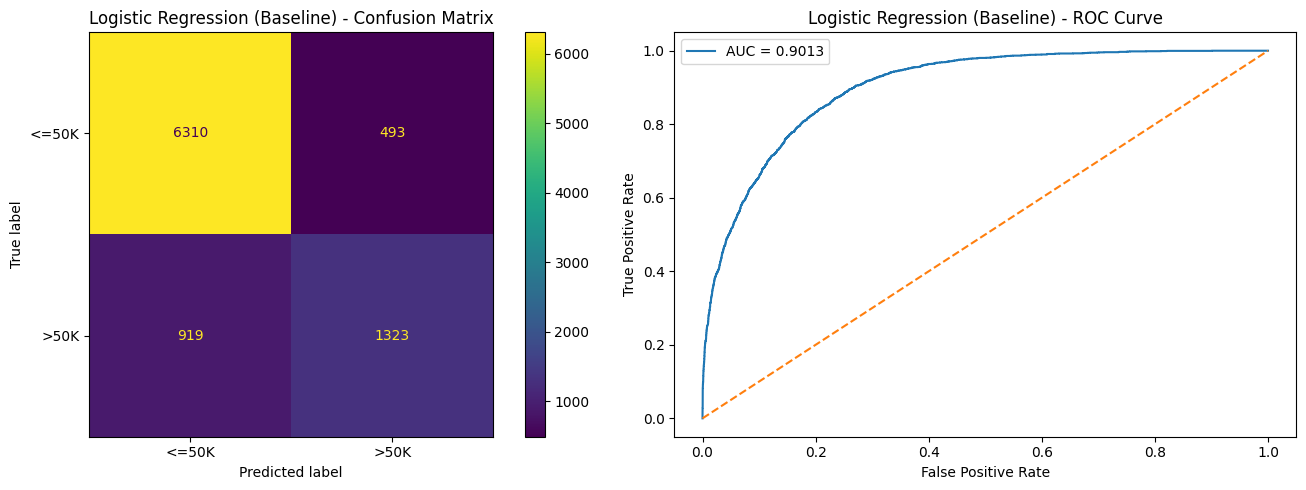


===== Decision Tree (Baseline) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.89      0.88      6803
        >50K       0.64      0.61      0.63      2242

    accuracy                           0.82      9045
   macro avg       0.76      0.75      0.75      9045
weighted avg       0.82      0.82      0.82      9045


AUC Score: 0.7739256950054699


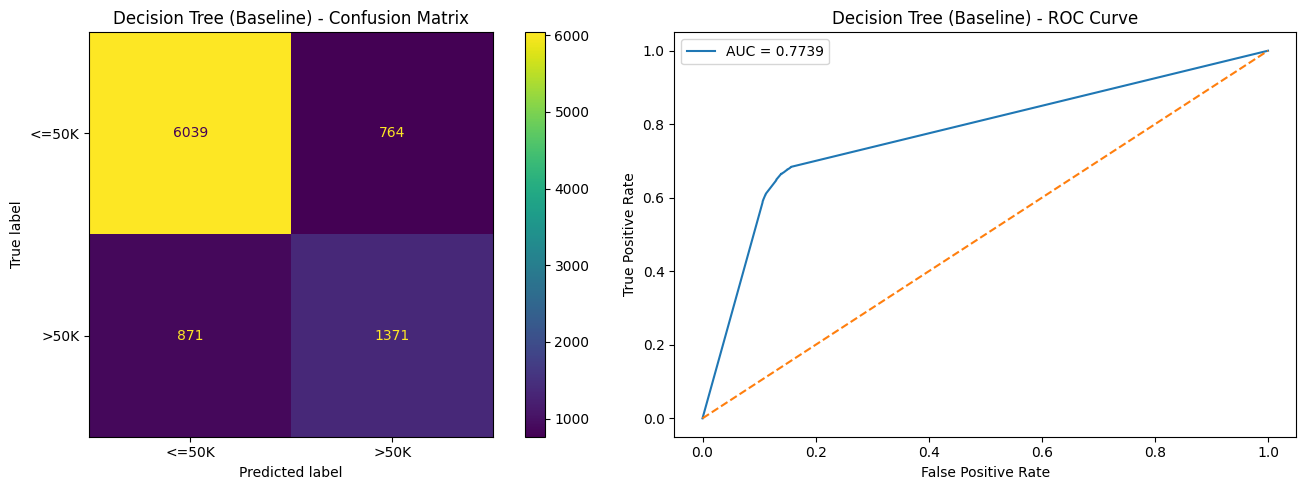


===== Random Forest (Baseline) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6803
        >50K       0.73      0.62      0.67      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.77      0.79      9045
weighted avg       0.84      0.85      0.85      9045


AUC Score: 0.8967139176018136


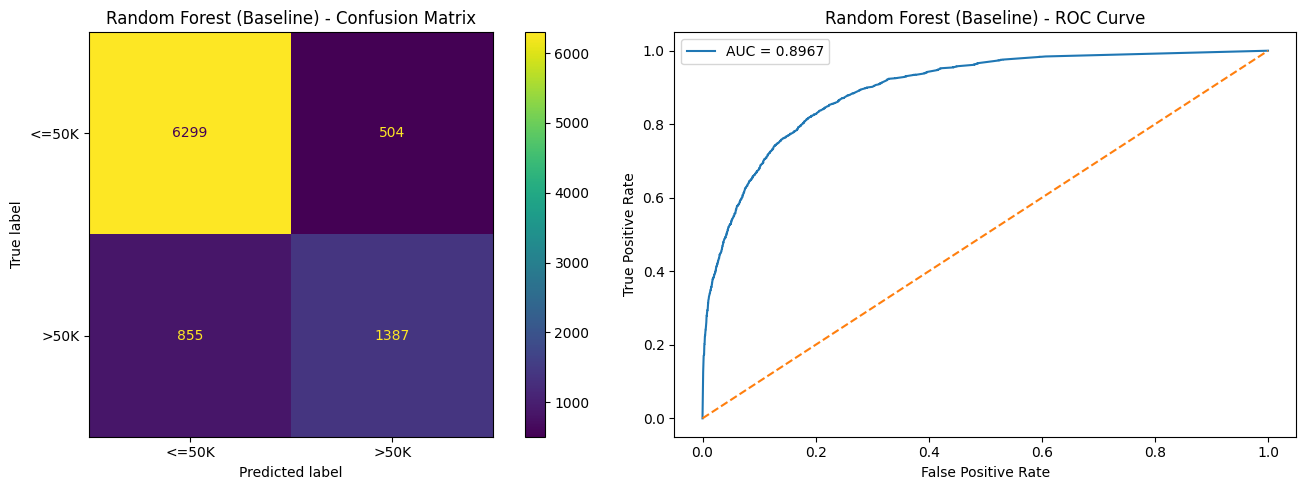

In [ ]:
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)

    print(f"\n===== {name} =====")

    # ROC Curve
    y_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)

    # define labels
    labels = ['<=50K', '>50K']
    # classification Report
    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=labels))
    print("\nAUC Score:", roc_auc)

    # creating a figure with 2
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0])
    axes[0].set_title(f"{name} - Confusion Matrix")

    # ROC
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle='--')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{name} - ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

evaluate_model(logistic_model, X_test, y_test, "Logistic Regression (Baseline)")
evaluate_model(dt_model, X_test, y_test, "Decision Tree (Baseline)")
evaluate_model(rf_model, X_test, y_test, "Random Forest (Baseline)")

# **Further fine-tuning the model**
---

1. **Imbalance handling**

To help manage the imbalanced dataset issue(75% <=50K, 25% >50K), `class_weight=balanced` is used to give more weight to the smaller class (>50K) when predicting.



In [ ]:
#logistic regression
logistic_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    ))
])

#decision tree
dt_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

#random forest
rf_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

#train all model
logistic_balanced.fit(X_train, y_train)
dt_balanced.fit(X_train, y_train)
rf_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'education-num']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


===== Logistic Regression (Baseline, Balanced) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      6803
        >50K       0.58      0.83      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.81      0.82      9045


AUC Score: 0.9011446844238707


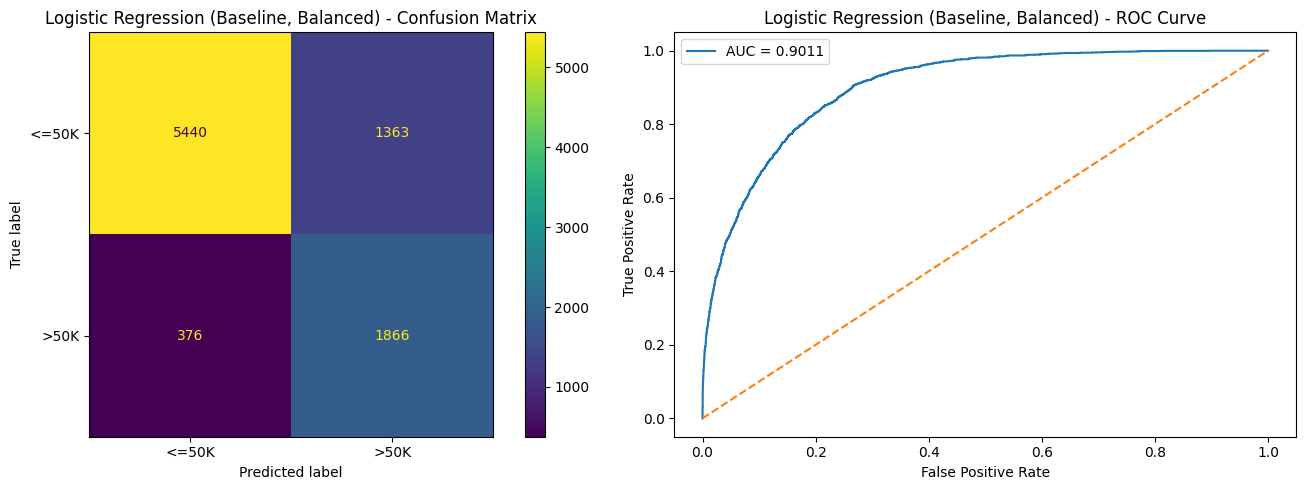


===== Decision Tree (Baseline, Balanced) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.86      0.87      6803
        >50K       0.61      0.66      0.63      2242

    accuracy                           0.81      9045
   macro avg       0.75      0.76      0.75      9045
weighted avg       0.82      0.81      0.81      9045


AUC Score: 0.7702173753695011


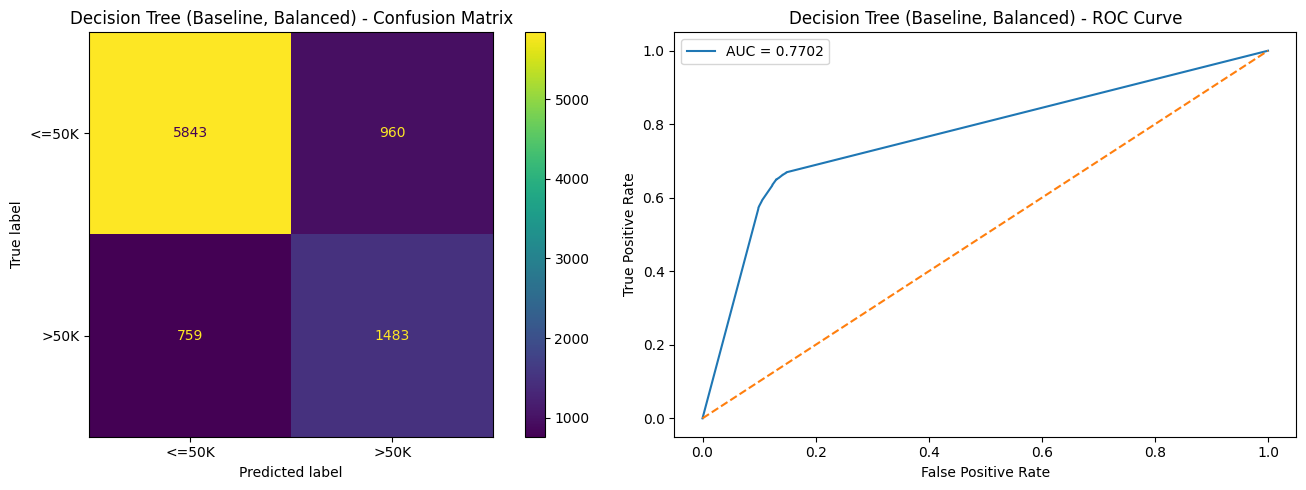


===== Random Forest (Baseline, Balanced) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      6803
        >50K       0.71      0.64      0.67      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.78      0.79      9045
weighted avg       0.84      0.85      0.84      9045


AUC Score: 0.8967345046257208


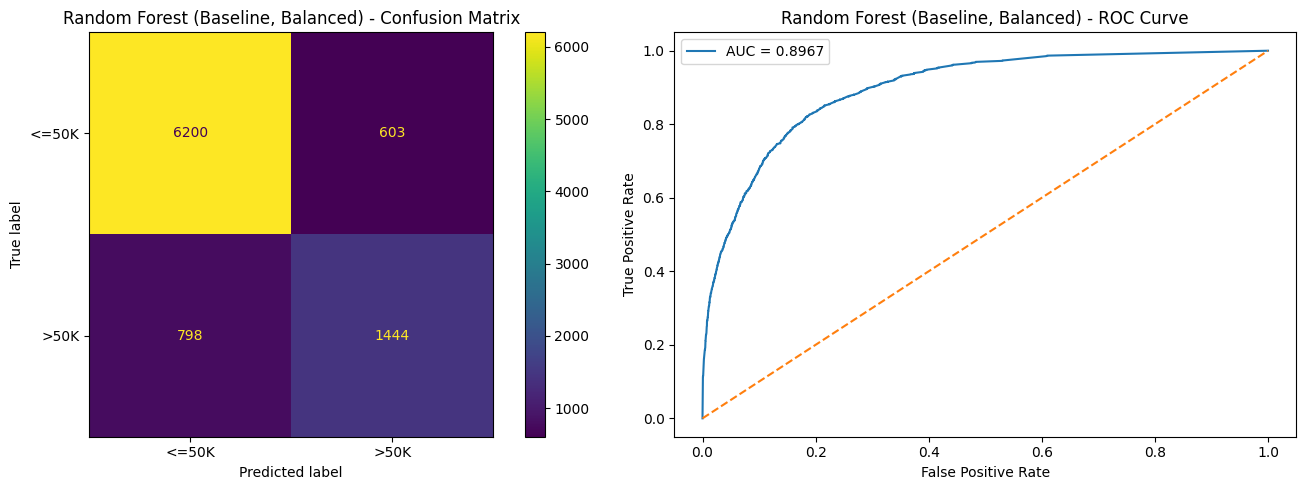

In [ ]:
evaluate_model(logistic_balanced, X_test, y_test, "Logistic Regression (Baseline, Balanced)")
evaluate_model(dt_balanced, X_test, y_test, "Decision Tree (Baseline, Balanced)")
evaluate_model(rf_balanced, X_test, y_test, "Random Forest (Baseline, Balanced)")

After imbalance handling, we do hyperparameter tuning

**2. Hyperparameter tuning**

We will use GridSearchCV, which:
1. performs cross validation
2. try multiple hyperparameter combination and automatically select the best one


In [ ]:
# initialise the stratified k fold object
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# Logistic Grid
param_grid_logistic = [
    {
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": ["balanced"],
        "classifier__random_state": [RANDOM_STATE]
    },
    {
        "classifier__penalty": ["l1", "l2"],
        "classifier__solver": ["liblinear", "saga"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": ["balanced"],
        "classifier__random_state": [RANDOM_STATE]
    }
]

grid_logistic = GridSearchCV(
    logistic_balanced,
    param_grid_logistic,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train)

print("Best Logistic Params:", grid_logistic.best_params_)

Best Logistic Params: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__random_state': 42, 'classifier__solver': 'liblinear'}


In [ ]:
param_grid_dt = {
    "classifier__max_depth": [None, 5, 10, 15, 20, 30],
    "classifier__min_samples_split": [20, 50, 75, 100],
    "classifier__min_samples_leaf": [2, 5, 10],
    "classifier__criterion": ["gini"],
    "classifier__class_weight": ["balanced"],
    "classifier__random_state": [RANDOM_STATE]
}

grid_dt = GridSearchCV(
    dt_balanced,
    param_grid_dt,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("\nBest Decision Tree Params:", grid_dt.best_params_)



Best Decision Tree Params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 20, 'classifier__random_state': 42}


In [ ]:
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [10, 20, 30, None],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__class_weight": ["balanced"],
    "classifier__random_state": [RANDOM_STATE]
}

grid_rf = GridSearchCV(
    rf_balanced,
    param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest Random Forest Params:", grid_rf.best_params_)


Best Random Forest Params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 30, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200, 'classifier__random_state': 42}



===== Logistic (Tuned) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      6803
        >50K       0.58      0.83      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.81      0.82      9045


AUC Score: 0.9005726405270907


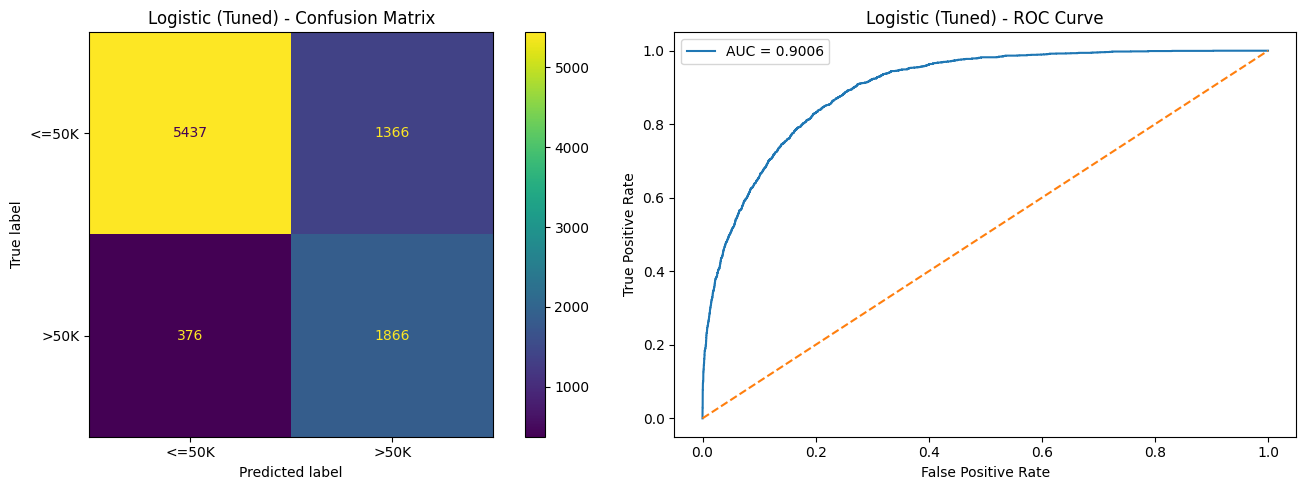


===== Decision Tree (Tuned) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.58      0.85      0.69      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.78      9045
weighted avg       0.85      0.81      0.82      9045


AUC Score: 0.9023504677253816


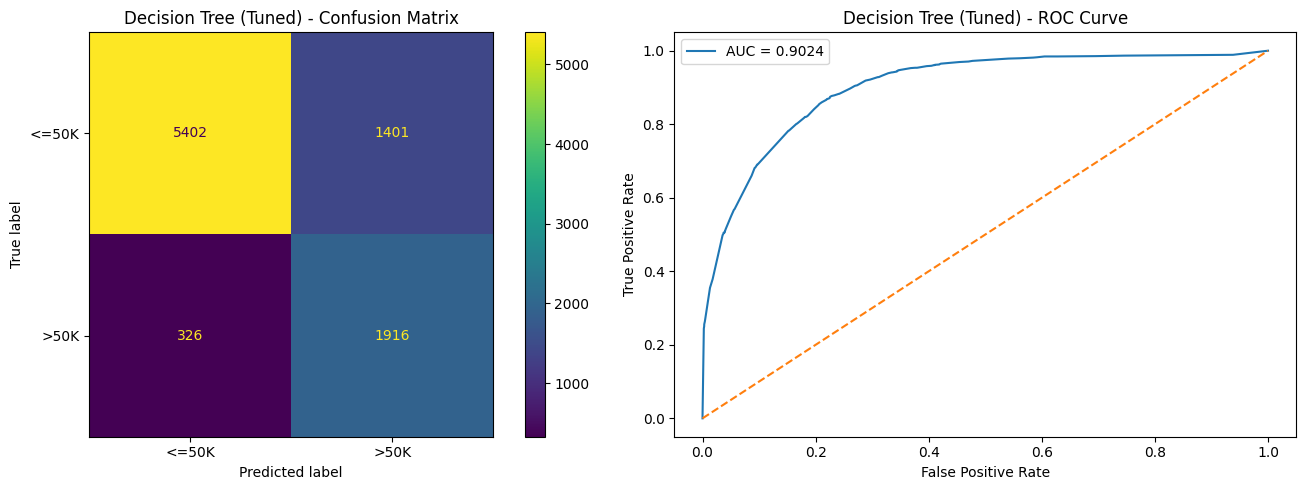


===== Random Forest (Tuned) =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.93      0.86      0.89      6803
        >50K       0.65      0.80      0.72      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.83      0.81      9045
weighted avg       0.86      0.84      0.85      9045


AUC Score: 0.9172291163983777


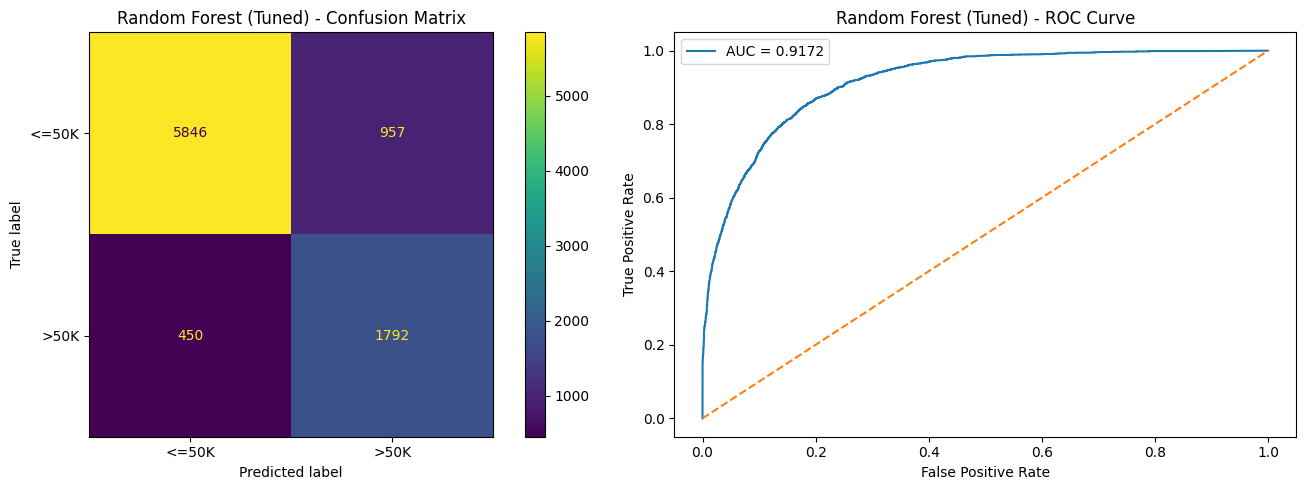

In [ ]:
# get the best param estimator for each model;
best_logistic = grid_logistic.best_estimator_
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

# evaluation on model after tuning
evaluate_model(best_logistic, X_test, y_test, "Logistic (Tuned)")
evaluate_model(best_dt, X_test, y_test, "Decision Tree (Tuned)")
evaluate_model(best_rf, X_test, y_test, "Random Forest (Tuned)")

3. Feature importance analysis on decision tree and random forest

In [ ]:
def plot_feature_importance(model, model_name, top_n=15):

    # get feature names after preprocessing
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()

    # get importance values
    importances = model.named_steps["classifier"].feature_importances_

    # create DataFrame
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    # show top features
    print(f"\nTop {top_n} Features – {model_name}")
    print(importance_df.head(top_n))


    top_features = importance_df.head(top_n)

    plt.figure()
    plt.barh(top_features["feature"], top_features["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Feature Importances – {model_name}")
    plt.xlabel("Importance")
    plt.show()


Top 15 Features – Decision Tree
                feature  importance
8     cat__relationship    0.506264
4    num__education-num    0.161193
1     num__capital-gain    0.159260
0              num__age    0.061953
3   num__hours-per-week    0.042940
2     num__capital-loss    0.040246
7       cat__occupation    0.014321
5        cat__workclass    0.007383
10             cat__sex    0.002608
11  cat__native-country    0.001726
9             cat__race    0.001708
6   cat__marital-status    0.000397


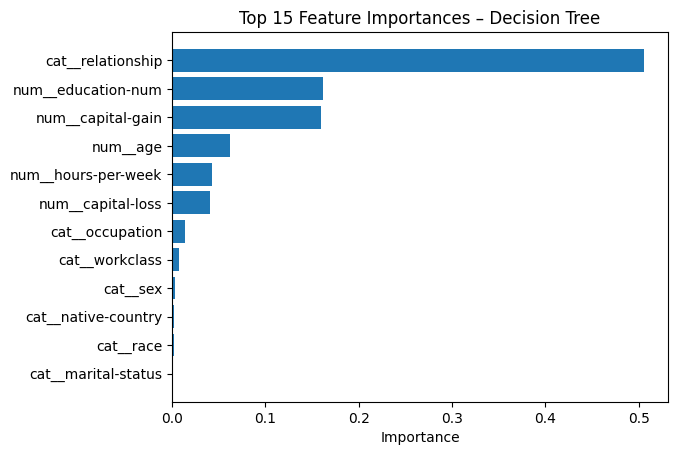


Top 15 Features – Random Forest
                feature  importance
8     cat__relationship    0.205568
0              num__age    0.158977
4    num__education-num    0.143599
6   cat__marital-status    0.131963
1     num__capital-gain    0.116797
3   num__hours-per-week    0.076847
7       cat__occupation    0.061608
2     num__capital-loss    0.034003
5        cat__workclass    0.027819
10             cat__sex    0.019308
11  cat__native-country    0.012646
9             cat__race    0.010866


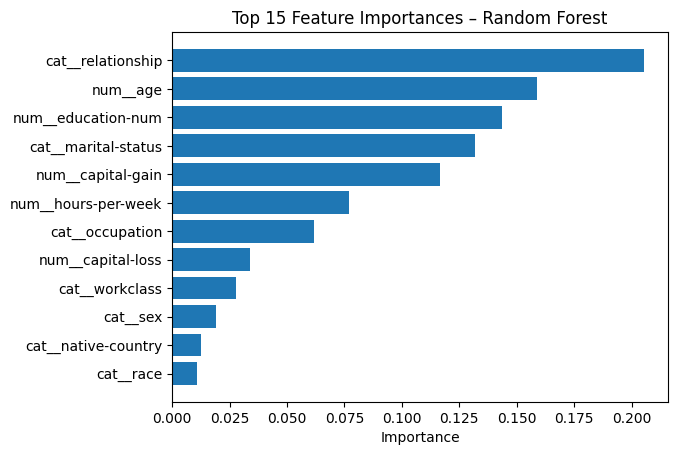

In [ ]:
#apply to decision tree and random forest
plot_feature_importance(best_dt, "Decision Tree")
plot_feature_importance(best_rf, "Random Forest")

In [ ]:
#compare the feature importance from both tree
dt_importance = best_dt.named_steps["classifier"].feature_importances_
rf_importance = best_rf.named_steps["classifier"].feature_importances_

print("Top RF Importance:", max(rf_importance))
print("Top DT Importance:", max(dt_importance))

Top RF Importance: 0.20556771618972847
Top DT Importance: 0.5062639694824745
